# Expresso Churn Prediction

**Dataset:** Expresso Churn Prediction Challenge - Zindi Africa  
**Rows:** ~2.15 million customers | **Features:** 19 columns  
**Goal:** Predict whether a customer will churn (stop using the service)

---
### Notebook Structure
1. Imports & Setup
2. Load Data & Basic Exploration
3. Data Cleaning
4. Encoding Categorical Features
5. Outlier Handling
6. Feature Scaling
7. Train-Test Split
8. Modelling
9. Model Evaluation
10. Save Model & Scaler

Dataset Source: Zindi Expresso Churn Prediction Challenge

---
## 1. Import Libraries

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

---
## 2. Load Data & Basic Exploration

In [160]:
# Load the dataset
# Place the CSV inside the data/ folder before running this cell
df = pd.read_csv('../data/Expresso_churn_dataset.csv')
data = df.copy()

print('Shape:', data.shape)

Shape: (2154048, 19)


In [161]:
# Data relationship: Read, Learn & Understand the data, column by column
# Check if the file has headers or comments

data.head(5)
data.tail(5)

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN
2154043,ffffe85215ddc71a84f95af0afb0deeea90e6967,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,6,NaN,NaN,0
2154044,ffffeaaa9289cdba0ac000f0ab4b48f4aa74ed15,THIES,K > 24 month,6100.0,15.0,5800.0,1933.0,15.0,621.0,26.0,40.0,40.0,NaN,NaN,NO,55,"Data: 200 F=100MB,24H",9.0,0
2154045,fffff172fda1b4bb38a95385951908bb92379809,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,1,NaN,NaN,1
2154046,fffff5911296937a37f09a37a549da2e0dad6dbb,THIES,K > 24 month,10000.0,11.0,7120.0,2373.0,13.0,NaN,0.0,140.0,13.0,NaN,NaN,NO,28,All-net 500F=2000F;5d,12.0,0
2154047,fffff6dbff1508ea2bfe814e5ab2729ce6b788c2,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NO,62,NaN,NaN,1


In [162]:
# Display general information about the dataset (info)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2154048 entries, 0 to 2154047
Data columns (total 19 columns):
 #   Column          Dtype  
---  ------          -----  
 0   user_id         object 
 1   REGION          object 
 2   TENURE          object 
 3   MONTANT         float64
 4   FREQUENCE_RECH  float64
 5   REVENUE         float64
 6   ARPU_SEGMENT    float64
 7   FREQUENCE       float64
 8   DATA_VOLUME     float64
 9   ON_NET          float64
 10  ORANGE          float64
 11  TIGO            float64
 12  ZONE1           float64
 13  ZONE2           float64
 14  MRG             object 
 15  REGULARITY      int64  
 16  TOP_PACK        object 
 17  FREQ_TOP_PACK   float64
 18  CHURN           int64  
dtypes: float64(12), int64(2), object(5)
memory usage: 312.2+ MB


In [163]:
# Display summary statistics of the dataset (describe)

data.describe()

,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK,CHURN
count,1.397309e+06,1.397309e+06,1.428000e+06,1.428000e+06,1.428000e+06,1.093615e+06,1.367373e+06,1.258800e+06,864032.000000,169721.000000,136824.000000,2.154048e+06,1.251454e+06,2.154048e+06
mean,5.532117e+03,1.152912e+01,5.510810e+03,1.836943e+03,1.397814e+01,3.366450e+03,2.776891e+02,9.541871e+01,23.109253,8.170132,7.553309,2.804251e+01,9.272461e+00,1.875474e-01
std,7.111339e+03,1.327407e+01,7.187113e+03,2.395700e+03,1.469403e+01,1.330446e+04,8.726889e+02,2.049873e+02,63.578086,41.169511,33.487234,2.228686e+01,1.228044e+01,3.903504e-01
min,1.000000e+01,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,0.000000e+00
25%,1.000000e+03,2.000000e+00,1.000000e+03,3.330000e+02,3.000000e+00,0.000000e+00,5.000000e+00,7.000000e+00,2.000000,0.000000,0.000000,6.000000e+00,2.000000e+00,0.000000e+00
50%,3.000000e+03,7.000000e+00,3.000000e+03,1.000000e+03,9.000000e+00,2.570000e+02,2.700000e+01,2.900000e+01,6.000000,1.000000,2.000000,2.400000e+01,5.000000e+00,0.000000e+00
75%,7.350000e+03,1.600000e+01,7.368000e+03,2.456000e+03,2.000000e+01,2.895000e+03,1.560000e+02,9.900000e+01,20.000000,3.000000,5.000000,5.100000e+01,1.200000e+01,0.000000e+00
max,4.700000e+05,1.330000e+02,5.321770e+05,1.773920e+05,9.100000e+01,1.823866e+06,5.080900e+04,2.132300e+04,4174.000000,4792.000000,3697.000000,6.200000e+01,7.130000e+02,1.000000e+00


In [164]:
# Missing values: count and percentage
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

                Missing Count  Missing %
ZONE2                 2017224       93.6
ZONE1                 1984327       92.1
TIGO                  1290016       59.9
DATA_VOLUME           1060433       49.2
FREQ_TOP_PACK          902594       41.9
TOP_PACK               902594       41.9
ORANGE                 895248       41.6
REGION                 849299       39.4
ON_NET                 786675       36.5
MONTANT                756739       35.1
FREQUENCE_RECH         756739       35.1
FREQUENCE              726048       33.7
REVENUE                726048       33.7
ARPU_SEGMENT           726048       33.7


CHURN value counts:
         Count  Percentage
CHURN                     
0      1750062        81.2
1       403986        18.8


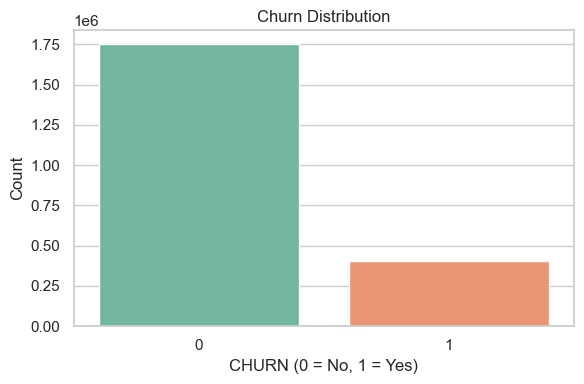


Note: The dataset is imbalanced, only ~18.8% of customers churned.
This will be handled using class_weight="balanced" in the model.


In [165]:
# Class balance: how many customers churned vs did not
churn_counts = data['CHURN'].value_counts()
churn_pct = data['CHURN'].value_counts(normalize=True) * 100

print('CHURN value counts:')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(1)}))

plt.figure(figsize=(6, 4))
sns.countplot(x='CHURN', data=data, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('CHURN (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../images/churn_distribution.png')
plt.show()

print('\nNote: The dataset is imbalanced, only ~18.8% of customers churned.')
print('This will be handled using class_weight="balanced" in the model.')

In [166]:
# REGION: unique values
print('REGION unique values:', sorted(data['REGION'].dropna().unique()))
print('REGION unique count:', data['REGION'].nunique())

REGION unique values: ['DAKAR', 'DIOURBEL', 'FATICK', 'KAFFRINE', 'KAOLACK', 'KEDOUGOU', 'KOLDA', 'LOUGA', 'MATAM', 'SAINT-LOUIS', 'SEDHIOU', 'TAMBACOUNDA', 'THIES', 'ZIGUINCHOR']
REGION unique count: 14


In [167]:
# TENURE: unique values (ordinal categories)
print('TENURE unique values:', sorted(data['TENURE'].dropna().unique()))

TENURE unique values: ['D 3-6 month', 'E 6-9 month', 'F 9-12 month', 'G 12-15 month', 'H 15-18 month', 'I 18-21 month', 'J 21-24 month', 'K > 24 month']


In [168]:
# MRG: check unique values (if only one value, it has no predictive power)
print('MRG unique values:', data['MRG'].unique())

MRG unique values: ['NO']


In [169]:
# Ensure correct data types: Verify that each feature has the correct data type for accurate analysis.

print(data.dtypes)
data.sample(3)

user_id            object
REGION             object
TENURE             object
MONTANT           float64
FREQUENCE_RECH    float64
REVENUE           float64
ARPU_SEGMENT      float64
FREQUENCE         float64
DATA_VOLUME       float64
ON_NET            float64
ORANGE            float64
TIGO              float64
ZONE1             float64
ZONE2             float64
MRG                object
REGULARITY          int64
TOP_PACK           object
FREQ_TOP_PACK     float64
CHURN               int64
dtype: object


,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN
1458150,ad523ac1426f99db54cae73da2959cf49d0df7f4,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,6,NaN,NaN,1
1757716,d0e7e783db64969b049adb600dc1905b1e1e5664,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,1,NaN,NaN,1
1841223,dad08970eba6b1674f9fa5c6bf405caa04bf92ba,NaN,K > 24 month,300.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,1,NaN,NaN,0


---
## 3. Data Cleaning


In [170]:
# Check for duplicate rows
n_dupes = data.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')
if n_dupes > 0:
    data = data.drop_duplicates()
    print(f'Dropped. New shape: {data.shape}')

Duplicate rows found: 0


### Columns to drop and why

| Column | Reason for Dropping |
|--------|---------------------|
| `user_id` | Customer identifier, not a behavioural feature |
| `MRG` | Only one unique value ('NO'), zero predictive power |
| `ZONE1` | 92.1% missing: too little data to be useful |
| `ZONE2` | 93.6% missing: too little data to be useful |
| `TOP_PACK` | 140 unique string categories: too high cardinality for this model |

In [171]:
# Drop columns that cannot contribute to the model
cols_to_drop = ['user_id', 'MRG', 'ZONE1', 'ZONE2', 'TOP_PACK']
data = data.drop(columns=cols_to_drop)

print(f'Remaining columns ({len(data.columns)}):')
print(data.columns.tolist())

Remaining columns (14):
['REGION', 'TENURE', 'MONTANT', 'FREQUENCE_RECH', 'REVENUE', 'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO', 'REGULARITY', 'FREQ_TOP_PACK', 'CHURN']


In [172]:
# Separate object (categorical) and numeric columns
object_columns = data.select_dtypes(include=['object']).columns.tolist()
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove CHURN from numeric_columns — it is the target, not a feature
numeric_columns = [col for col in numeric_columns if col != 'CHURN']

print('Categorical columns:', object_columns)
print('Numeric columns:', numeric_columns)

Categorical columns: ['REGION', 'TENURE']
Numeric columns: ['MONTANT', 'FREQUENCE_RECH', 'REVENUE', 'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO', 'REGULARITY', 'FREQ_TOP_PACK']


In [173]:
# Handle missing values
# Strategy: median for numeric columns (robust to skew), mode for categorical columns
# NOTE: We do NOT call dropna() first, that would discard useful data.
# We impute instead, then drop any remaining rows that could not be filled.

# Fill numeric columns with median
for col in numeric_columns:
    data[col] = data[col].fillna(data[col].median())

# Fill categorical columns with mode
for col in object_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

# Verify no missing values remain
print('Missing values after imputation:')
print(data.isnull().sum()[data.isnull().sum() > 0])
print('None remaining.' if data.isnull().sum().sum() == 0 else '')

Missing values after imputation:
Series([], dtype: int64)
None remaining.


---
## 4. Encoding Categorical Features

Two categorical columns remain: `REGION` and `TENURE`.

- **REGION** (14 named regions): Label Encoding. We save the encoder so the Streamlit app can use the same mapping.
- **TENURE** (8 ordered bands): Ordinal Encoding. The order matters (3–6 months < 6–9 months < ... > 24 months), so we map them to integers 0–7.

In [174]:
# REGION: Label Encoding
region_encoder = LabelEncoder()
data['REGION'] = region_encoder.fit_transform(data['REGION'])

# Save the region encoder for use in the Streamlit app
with open('../region_encoder.pkl', 'wb') as f:
    pickle.dump(region_encoder, f)

print('REGION encoding map:')
for name, code in zip(region_encoder.classes_, region_encoder.transform(region_encoder.classes_)):
    print(f'  {name} → {code}')

REGION encoding map:
  DAKAR → 0
  DIOURBEL → 1
  FATICK → 2
  KAFFRINE → 3
  KAOLACK → 4
  KEDOUGOU → 5
  KOLDA → 6
  LOUGA → 7
  MATAM → 8
  SAINT-LOUIS → 9
  SEDHIOU → 10
  TAMBACOUNDA → 11
  THIES → 12
  ZIGUINCHOR → 13


In [175]:
# TENURE: Ordinal Encoding (order matters)
tenure_order = [
    'D 3-6 month',
    'E 6-9 month',
    'F 9-12 month',
    'G 12-15 month',
    'H 15-18 month',
    'I 18-21 month',
    'J 21-24 month',
    'K > 24 month'
]
tenure_map = {label: i for i, label in enumerate(tenure_order)}
data['TENURE'] = data['TENURE'].map(tenure_map)

print('TENURE encoding map:')
for k, v in tenure_map.items():
    print(f'  {k} → {v}')

TENURE encoding map:
  D 3-6 month → 0
  E 6-9 month → 1
  F 9-12 month → 2
  G 12-15 month → 3
  H 15-18 month → 4
  I 18-21 month → 5
  J 21-24 month → 6
  K > 24 month → 7


---
## 5. Outlier Handling

Outliers are replaced with the column median.

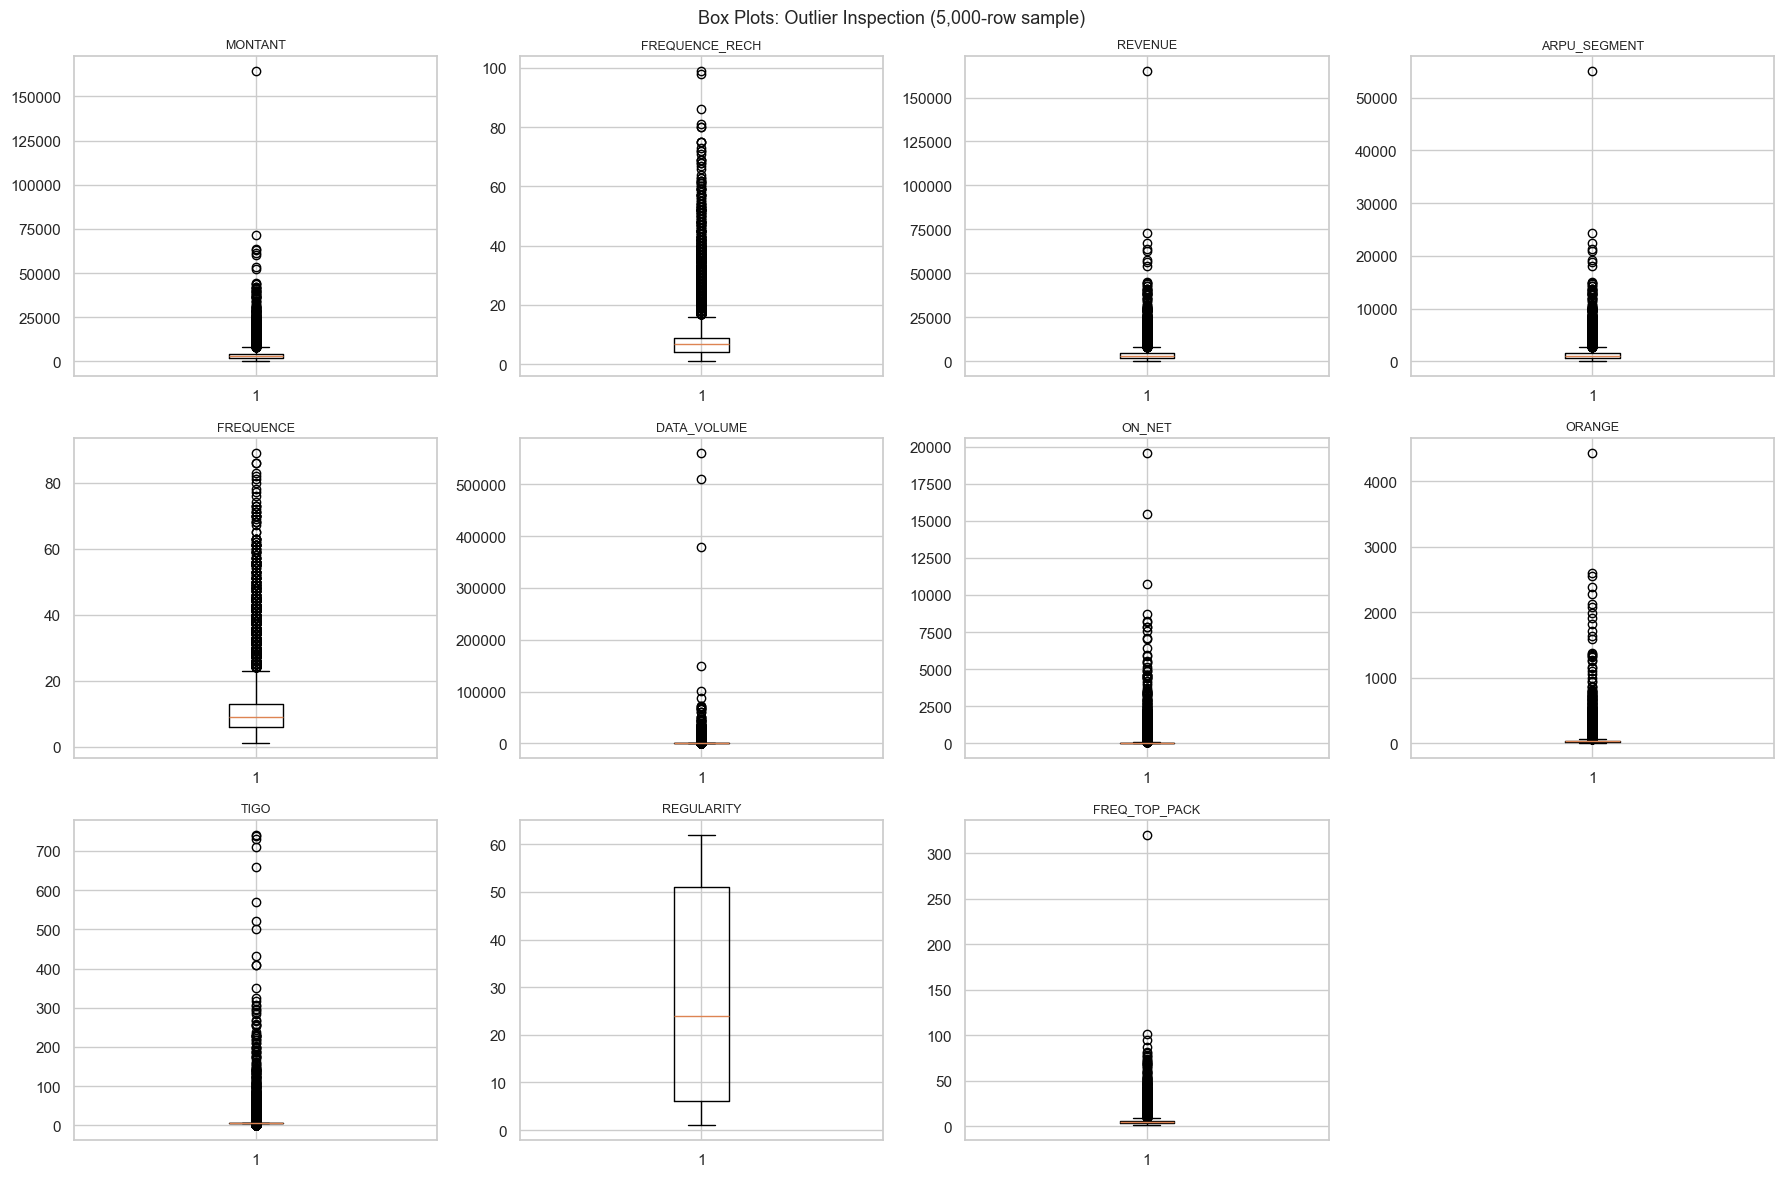

In [176]:
# Visualise distributions to identify columns with significant outliers
# (using a sample for speed)
sample = data.sample(5000, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_columns[:12]):
    axes[i].boxplot(sample[col].dropna())
    axes[i].set_title(col, fontsize=9)

for j in range(len(numeric_columns[:12]), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots: Outlier Inspection (5,000-row sample)', fontsize=13)
plt.tight_layout()
plt.savefig('../images/boxplots.png')
plt.show()

In [177]:
# Cap outliers using IQR method
columns_to_handle = ['MONTANT', 'REVENUE', 'ARPU_SEGMENT', 'DATA_VOLUME', 'ON_NET',
                     'ORANGE', 'TIGO', 'FREQUENCE', 'FREQUENCE_RECH', 'FREQ_TOP_PACK']

for col in columns_to_handle:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    median = data[col].median()
    data[col] = np.where(
        (data[col] > upper) | (data[col] < lower),
        median,
        data[col]
    )

print('Outlier capping complete.')

Outlier capping complete.


---
## 6. Train-Test Split

In [178]:
# Define features and target
feature_cols = [col for col in data.columns if col != 'CHURN']

X = data[feature_cols]
y = data['CHURN']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')

Training set : 1,507,833 rows
Test set     : 646,215 rows


---
## 7. Feature Scaling

> **Important:** We scale only the feature columns, NOT the target (`CHURN`).
> We save the scaler so the Streamlit app applies the exact same transformation to new inputs.

In [179]:
# Scale features only
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler — required for the Streamlit app to scale user inputs correctly
with open('../scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Scaler saved.')
print(f'Features scaled: {feature_cols}')



Scaler saved.
Features scaled: ['REGION', 'TENURE', 'MONTANT', 'FREQUENCE_RECH', 'REVENUE', 'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO', 'REGULARITY', 'FREQ_TOP_PACK']


---
## 8. Modelling

We use Logistic Regression with `class_weight='balanced'` to account for the class imbalance (81.2% non-churn vs 18.8% churn). Without this, the model would simply predict 'not churned' for most customers and still achieve high accuracy, which is misleading.

In [180]:
# Logistic Regression with class_weight='balanced' to handle imbalance
model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=1)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print('Model training complete.')

Model training complete.


---
## 9. Model Evaluation

Accuracy alone is not enough for imbalanced data. We use:
- **Confusion Matrix**: shows actual vs predicted counts
- **Classification Report**: precision, recall, F1 per class
- **ROC-AUC Score**: measures overall discrimination ability

In [181]:
# Accuracy
accuracy = model.score(X_test_scaled, y_test)
print(f'Accuracy : {accuracy:.4f}')

# ROC-AUC
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
print(f'ROC-AUC  : {roc_auc:.4f}')

Accuracy : 0.7945
ROC-AUC  : 0.9076


In [182]:
# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.97      0.77      0.86    525019
     Churned       0.47      0.90      0.62    121196

    accuracy                           0.79    646215
   macro avg       0.72      0.83      0.74    646215
weighted avg       0.88      0.79      0.81    646215



The model achieved a ROC-AUC score of 0.9076, which suggests strong ability to separate churned and non-churned customers.

The recall for churned customers is 0.90, meaning the model correctly identifies most customers who are likely to churn. However, the precision for churned customers is 0.47, meaning some customers predicted as churned did not actually churn.

For a telecom business, this model may still be useful for low-cost retention campaigns because it prioritises identifying customers at risk of leaving.

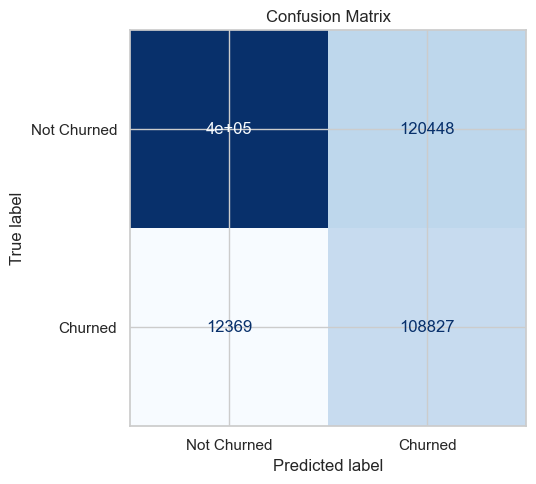

In [183]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned', 'Churned'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png')
plt.show()

---
## 10. Save Model & Scaler

In [184]:
# Save the trained model
with open('../model.pkl', 'wb') as f:
    pickle.dump(model, f)

print('model.pkl saved')
print('scaler.pkl saved (done in Section 6)')
print('region_encoder.pkl saved (done in Section 4)')
print()
print('All three files are required for the Streamlit app to work correctly.')

model.pkl saved
scaler.pkl saved (done in Section 6)
region_encoder.pkl saved (done in Section 4)

All three files are required for the Streamlit app to work correctly.
